In [1]:
import numpy as np

# Load the data
images = np.load("data/images.npy")
labels = np.load("data/labels.npy")

# Print basic info
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Data type of images:", images.dtype)
print("Data type of labels:", labels.dtype)



Images shape: (1000, 16, 16)
Labels shape: (1000,)
Data type of images: float64
Data type of labels: int64


C:\Users\anmol\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


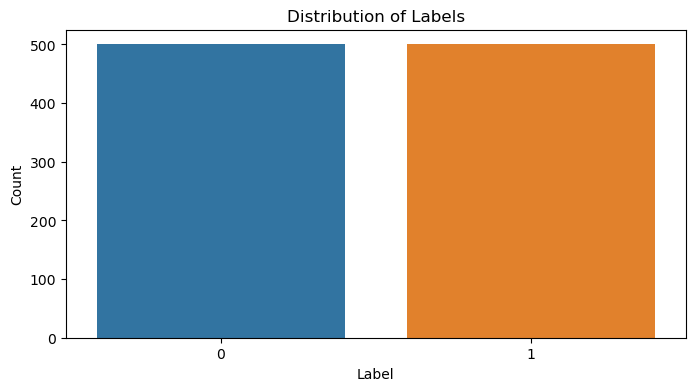

Unique labels: [0 1]
Label counts: [500 500]


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Unique label counts
unique_labels, label_counts = np.unique(labels, return_counts=True)

# Plot label distribution
plt.figure(figsize=(8, 4))
sns.barplot(x=unique_labels, y=label_counts)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels")
plt.show()

print("Unique labels:", unique_labels)
print("Label counts:", label_counts)


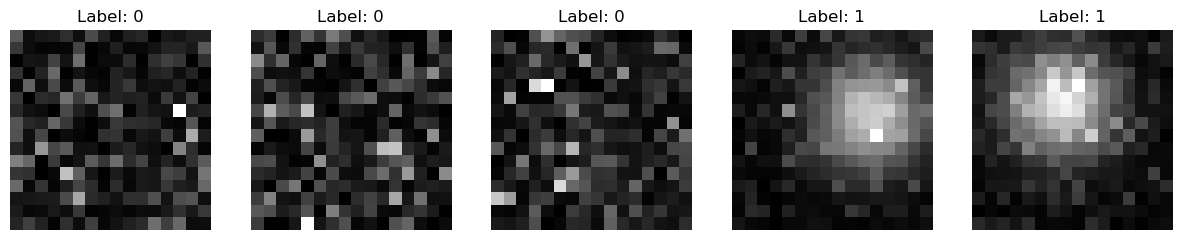

In [7]:
import matplotlib.pyplot as plt

# Plot sample images
num_samples = 5  # Adjust if needed
fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

for i in range(num_samples):
    axes[i].imshow(images[i], cmap='gray')  # Change 'gray' if RGB
    axes[i].axis("off")
    axes[i].set_title(f"Label: {labels[i]}")

plt.show()


In [4]:
# Check for NaN values
print("Any NaN in images?", np.isnan(images).any())
print("Any NaN in labels?", np.isnan(labels).any())

# Check for duplicate images
num_unique_images = len(np.unique(images, axis=0))
print(f"Total images: {len(images)}, Unique images: {num_unique_images}")


Any NaN in images? False
Any NaN in labels? False
Total images: 1000, Unique images: 1000


In [8]:
import os
print(os.listdir("model/"))


['fingerprint.pb', 'keras_metadata.pb', 'saved_model.pb', 'variables']


In [11]:
!pip install tensorflow




  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/cf/24/271e77c22724f370c24c705f394b8035b4d27e4c2c6339f3f45ab9b8258e/tensorflow-2.18.0-cp311-cp311-win_amd64.whl.metadata
  Using cached tensorflow-2.18.0-cp311-cp311-win_amd64.whl.metadata (3.3 kB)
  Obtaining dependency information for tensorflow-intel==2.18.0 from https://files.pythonhosted.org/packages/76/ad/fa6c508a15ff79cb5409294c293388e0999b7d480f84b65e4287277434fe/tensorflow_intel-2.18.0-cp311-cp311-win_amd64.whl.metadata
  Using cached tensorflow_intel-2.18.0-cp311-cp311-win_amd64.whl.metadata (4.9 kB)
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/a2/ad/e0d3c824784ff121c03cc031f944bc7e139a8f1870ffd2845cc2dd76f6c4/absl_py-2.1.0-py3-none-any.whl.metadata
  Using cached absl_py-2.1.0-py3-none-any.whl.metadata (2.3 kB)
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7

In [12]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.18.0


In [14]:
import tensorflow as tf

# Load the model using TensorFlow's saved_model.load()
model = tf.saved_model.load("model/")

# Print model signatures (useful for inference)
print("Model Loaded Successfully!")
print("Available Signatures:", list(model.signatures.keys()))



Model Loaded Successfully!
Available Signatures: ['serving_default']


In [15]:
print(model.signatures["serving_default"])


ConcreteFunction Input Parameters:
  input_1 (KEYWORD_ONLY): TensorSpec(shape=(None, 16, 16), dtype=tf.float32, name='input_1')
Output Type:
  Dict[['lambda', TensorSpec(shape=(None,), dtype=tf.float32, name='lambda')]]
Captures:
  None


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.image import resize

# Load dataset
images = np.load("data/images.npy").astype("float32") / 255.0  # Normalize
labels = np.load("data/labels.npy")

# Ensure images have a channel dimension (H, W, 1)
if len(images.shape) == 3:  # If shape is (N, H, W), add channel dim
    images = np.expand_dims(images, axis=-1)  # Convert to (N, H, W, 1)

# Resize images to match model input (16x16)
images_resized = resize(images, (16, 16))  # TensorFlow handles batch resizing

# Convert to NumPy array
images_resized = images_resized.numpy()

# Convert to TensorFlow tensor
input_tensor = tf.convert_to_tensor(images_resized)

print("New shape of images:", images_resized.shape)



New shape of images: (1000, 16, 16, 1)


In [28]:
# Get the inference function
infer = model.signatures["serving_default"]

# Run inference
predictions = infer(input_tensor)["lambda"]  # Extract output tensor

# Convert to NumPy array
predictions = predictions.numpy()

print("Predictions:", predictions[:10])  # Print first 10 predictions


Predictions: [[0.9596251 ]
 [0.96631384]
 [1.0449318 ]
 [1.1289663 ]
 [1.1334177 ]
 [1.0712624 ]
 [1.093499  ]
 [1.1031672 ]
 [0.98775053]
 [1.1091473 ]]


In [19]:
from sklearn.metrics import mean_squared_error

# Convert predictions to 1D array
predictions = predictions.flatten()

# Compute Mean Squared Error
mse = mean_squared_error(labels, predictions)
print(f"Mean Squared Error (MSE): {mse:.4f}")


Mean Squared Error (MSE): 0.5114


In [20]:
import numpy as np

# Load labels
labels = np.load("data/labels.npy")

# Print unique values in labels
print("Unique labels:", np.unique(labels))
print("Label data type:", labels.dtype)


Unique labels: [0 1]
Label data type: int64


In [21]:
import numpy as np
from sklearn.metrics import accuracy_score

# Convert continuous outputs to class labels (0 or 1)
predicted_labels = (predictions >= 0.5).astype(int)  # Convert to binary classes

# Compute accuracy
accuracy = accuracy_score(labels, predicted_labels)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 50.00%


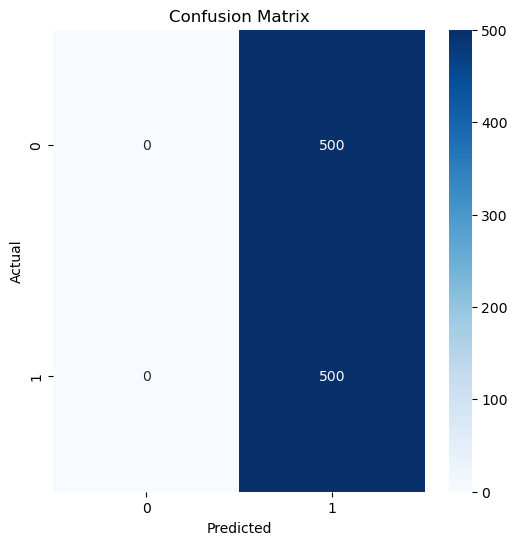

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       500
           1       0.50      1.00      0.67       500

    accuracy                           0.50      1000
   macro avg       0.25      0.50      0.33      1000
weighted avg       0.25      0.50      0.33      1000



C:\Users\anmol\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anmol\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anmol\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(labels, predicted_labels)

# Visualize confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print(classification_report(labels, predicted_labels))


In [29]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Load dataset
images = np.load("data/images.npy").astype("float32") / 255.0  # Normalize pixel values
labels = np.load("data/labels.npy")

# Ensure images are in (16,16,1) format
if len(images.shape) == 3:
    images = np.expand_dims(images, axis=-1)  # Convert (N, H, W) -> (N, H, W, 1)

# Split dataset into training (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

print("Training Data Shape:", X_train.shape)
print("Validation Data Shape:", X_val.shape)


Training Data Shape: (800, 16, 16, 1)
Validation Data Shape: (200, 16, 16, 1)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(16, 16, 1)),  # Feature extraction
    MaxPooling2D((2,2)),  # Reduce dimensions
    Conv2D(64, (3,3), activation='relu'),  
    MaxPooling2D((2,2)),  
    Flatten(),  # Convert to 1D
    Dense(64, activation='relu'),  # Fully connected layer
    Dropout(0.3),  # Reduce overfitting
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Print model summary
model.summary()


C:\Users\anmol\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 14, 14, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 5, 5, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 35,329 (138.00 KB)

 Trainable params: 35,329 (138.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [32]:
from tensorflow.keras.callbacks import EarlyStopping

# Use early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32, callbacks=[early_stop])


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6274 - loss: 0.6909 - val_accuracy: 0.5150 - val_loss: 0.6764
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6972 - loss: 0.6653 - val_accuracy: 0.9050 - val_loss: 0.5874
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8401 - loss: 0.5361 - val_accuracy: 0.9900 - val_loss: 0.3860
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9661 - loss: 0.3173 - val_accuracy: 0.9900 - val_loss: 0.1587
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.1172 - val_accuracy: 1.0000 - val_loss: 0.0498
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9996 - loss: 0.0474 - val_accuracy: 1.0000 - val_loss: 0.0224
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0228 - val_accuracy: 1.0000 - val_loss: 0.0161
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0161 - val_accuracy: 1.0000 - val_loss

In [33]:
# Evaluate on validation set
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0011     
Validation Accuracy: 100.00%


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


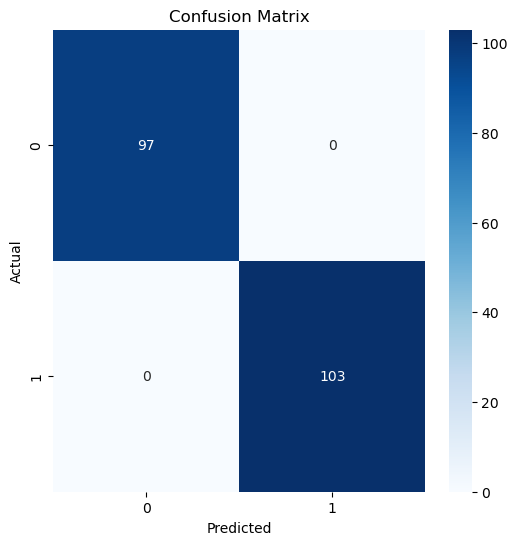

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        97
           1       1.00      1.00      1.00       103

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on validation set
y_pred = (model.predict(X_val) >= 0.5).astype(int)  # Convert probabilities to 0 or 1

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print(classification_report(y_val, y_pred))


In [36]:
model.save("final_model.keras") 
